# Day-level Merge + GK Volatility + Histograms

Updates in this notebook:
1. Merge by **stock + date(day)** (ignore time).
2. Concatenate `title` with semicolons and drop `url`.
3. Compute `gk_volatility` using t+1 OHLC.
4. Drop all `t_plus_1_*` columns to avoid leakage.
5. No daily/weekly aggregation is added to `eda_df`.
6. Add only `log_gk_volatility = log(gk_volatility + 1e-10)`.
7. Plot histogram of row-level `gk_volatility`.
8. Plot histogram of row-level `log_gk_volatility`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
input_path = Path("data/expanded_equities.parquet")
raw_df = pd.read_parquet(input_path)

print("raw_shape =", raw_df.shape)
print("raw_columns =", len(raw_df.columns))
raw_df.head(10)

raw_shape = (650985, 61)
raw_columns = 61


,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.820000,91.739998,89.820000,91.139999,2227500.0,90.650002,...,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0,Healthcare,Diagnostics & Research
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.000000,90.629997,89.110001,90.290001,1682800.0,88.040001,...,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0,Healthcare,Diagnostics & Research
2,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.000000,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0,Healthcare,Diagnostics & Research
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00-04:00,A,https://www.benzinga.com/news/20/05/16095921/4...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00-04:00,A,https://www.benzinga.com/news/20/05/16095304/b...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
5,"CFRA Maintains Hold on Agilent Technologies, L...",2020-05-22 11:23:00-04:00,A,https://www.benzinga.com/news/20/05/16095163/c...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
6,"UBS Maintains Neutral on Agilent Technologies,...",2020-05-22 09:36:00-04:00,A,https://www.benzinga.com/news/20/05/16094027/u...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
7,Agilent Technologies shares are trading higher...,2020-05-22 09:07:00-04:00,A,https://www.benzinga.com/wiim/20/05/16093805/a...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
8,Wells Fargo Maintains Overweight on Agilent Te...,2020-05-22 08:37:00-04:00,A,https://www.benzinga.com/news/20/05/16093505/w...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
9,10 Biggest Price Target Changes For Friday,2020-05-22 08:06:00-04:00,A,https://www.benzinga.com/analyst-ratings/price...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research


In [3]:
# Merge by stock + day (ignore intraday timestamp).
tmp = raw_df.copy()
tmp["date_ts"] = pd.to_datetime(tmp["date"], utc=True, errors="coerce")
tmp["date_day"] = tmp["date_ts"].dt.floor("D").dt.tz_localize(None)

KEY_COLS = ["stock", "date_day"]
EXCLUDE_COLS = {"title", "url", "date", "date_ts", "date_day"}
value_cols = [c for c in tmp.columns if c not in EXCLUDE_COLS]


def join_unique_titles(series: pd.Series) -> str:
    vals = pd.unique(series.dropna().astype(str))
    return "; ".join(vals)


agg_map = {c: "first" for c in value_cols}
agg_map["title"] = join_unique_titles

merged_df = tmp.groupby(KEY_COLS, as_index=False, sort=False).agg(agg_map)
merged_df = merged_df.rename(columns={"date_day": "date"})

ordered = ["date", "stock", "title"] + [
    c for c in raw_df.columns if c not in {"date", "stock", "title", "url"}
]
eda_df = merged_df[[c for c in ordered if c in merged_df.columns]].copy()

print("merged_shape =", eda_df.shape)
print("rows_removed =", raw_df.shape[0] - eda_df.shape[0])
print("has_url =", "url" in eda_df.columns)
print(
    "duplicate_keys_after_merge(stock+day) =",
    int(eda_df.duplicated(["stock", "date"]).sum()),
)
eda_df.head(10)

merged_shape = (381047, 60)
rows_removed = 269938
has_url = False
duplicate_keys_after_merge(stock+day) = 0


,date,stock,title,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,t_minus_2_high,...,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry
0,2020-06-05,A,Stocks That Hit 52-Week Highs On Friday,89.820000,91.739998,89.820000,91.139999,2227500.0,90.650002,91.139999,...,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0,Healthcare,Diagnostics & Research
1,2020-06-03,A,Stocks That Hit 52-Week Highs On Wednesday,90.000000,90.629997,89.110001,90.290001,1682800.0,88.040001,89.980003,...,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0,Healthcare,Diagnostics & Research
2,2020-05-26,A,71 Biggest Movers From Friday,85.000000,87.669998,84.199997,84.980003,5063100.0,81.720001,82.190002,...,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0,Healthcare,Diagnostics & Research
3,2020-05-22,A,46 Stocks Moving In Friday's Mid-Day Session; ...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
4,2020-05-21,A,8 Stocks Moving In Thursday's After-Hours Sess...,82.980003,82.980003,81.470001,81.709999,2748100.0,83.230003,83.540001,...,77.540001,78.500000,1190600.0,85.000000,87.669998,84.199997,84.980003,5063100.0,Healthcare,Diagnostics & Research
5,2020-05-18,A,Agilent Technologies Receives FDA Approval for...,81.510002,82.830002,81.220001,81.589996,4529400.0,79.290001,81.660004,...,73.419998,74.559998,1555400.0,83.230003,83.540001,81.889999,81.970001,2099200.0,Healthcare,Diagnostics & Research
6,2020-05-16,A,"Q1 13F Roundup: How Buffett, Einhorn, Ackman A...",81.510002,82.830002,81.220001,81.589996,4529400.0,79.290001,81.660004,...,73.419998,74.559998,1555400.0,83.239998,84.389999,82.290001,83.660004,2076000.0,Healthcare,Diagnostics & Research
7,2020-05-15,A,Pershing Square 13F Shows Fund Raises Stake In...,79.290001,81.660004,78.720001,81.639999,2285900.0,80.379997,81.930000,...,73.570000,74.209999,1618600.0,83.239998,84.389999,82.290001,83.660004,2076000.0,Healthcare,Diagnostics & Research
8,2020-05-08,A,How Bill Ackman Successfully Navigated Coronav...,78.769997,79.330002,77.540001,78.500000,1190600.0,76.690002,78.830002,...,74.019997,75.750000,1654300.0,79.599998,81.989998,79.500000,81.269997,1691600.0,Healthcare,Diagnostics & Research
9,2020-05-05,A,Shares of several healthcare companies are tra...,74.279999,74.620003,73.419998,74.559998,1555400.0,75.550003,76.099998,...,73.709999,73.750000,2848100.0,76.690002,78.830002,76.650002,77.870003,2303600.0,Healthcare,Diagnostics & Research


In [4]:
# Compute GK variance (sigma^2).
o = pd.to_numeric(eda_df["t_plus_1_open"], errors="coerce")
h = pd.to_numeric(eda_df["t_plus_1_high"], errors="coerce")
l = pd.to_numeric(eda_df["t_plus_1_low"], errors="coerce")
c = pd.to_numeric(eda_df["t_plus_1_close"], errors="coerce")

invalid = (o <= 0) | (h <= 0) | (l <= 0) | (c <= 0)
gk_sigma2 = 0.5 * (np.log(h / l) ** 2) - (2 * np.log(2) - 1) * (np.log(c / o) ** 2)
eda_df["gk_volatility"] = gk_sigma2.mask(invalid, np.nan)

print("gk_volatility null_count =", int(eda_df["gk_volatility"].isna().sum()))
eda_df["gk_volatility"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

gk_volatility null_count = 0


count    381047.000000
mean          0.001252
std           0.007451
min           0.000000
1%            0.000012
5%            0.000032
50%           0.000265
95%           0.004474
99%           0.015339
max           1.019725
Name: gk_volatility, dtype: float64

去除当日未发生交易的stock(gk_volatility为0)

In [5]:
eda_df[eda_df["gk_volatility"] == 0].head(10)

,date,stock,title,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,t_minus_2_high,...,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry,gk_volatility
421,2019-05-13,AAME,Atlantic American Q1 EPS $0.19 Up From $(0.25)...,2.510000,2.510000,2.480000,2.490000,1100.0,2.350000,2.350000,...,2.360000,200.0,2.450000,2.450000,2.450000,2.450000,100.0,Financial Services,Insurance - Life,0.0
426,2018-08-08,AAME,"Stocks Which Set New 52-Week Low Yesterday, Au...",2.360000,2.600000,2.200000,2.500000,9300.0,2.650000,2.650000,...,2.400000,1000.0,2.500000,2.500000,2.500000,2.500000,100.0,Financial Services,Insurance - Life,0.0
428,2018-03-26,AAME,Atlantic American Q4 EPS $0.12 vs $0.06 In Sam...,3.130000,3.250000,3.100000,3.250000,1100.0,3.100000,3.250000,...,3.430000,3300.0,3.250000,3.250000,3.250000,3.250000,0.0,Financial Services,Insurance - Life,0.0
433,2016-11-14,AAME,Atlantic American Reports Q3 EPS $0.00 vs. Pri...,3.600000,3.650000,3.500000,3.650000,1200.0,3.600000,3.700000,...,4.050000,4000.0,3.700000,3.700000,3.700000,3.700000,0.0,Financial Services,Insurance - Life,0.0
434,2016-08-11,AAME,Atlantic American Reports Q2 EPS $0.01 vs $0.1...,4.100000,4.150000,4.100000,4.100000,800.0,4.100000,4.160000,...,4.200000,700.0,4.060000,4.060000,4.060000,4.060000,0.0,Financial Services,Insurance - Life,0.0
435,2016-05-12,AAME,Atlantic American Reports Q1 EPS $0.04 vs $0.0...,3.950000,3.950000,3.950000,3.950000,400.0,4.100000,4.100000,...,4.310000,3700.0,3.870000,3.870000,3.870000,3.870000,100.0,Financial Services,Insurance - Life,0.0
460,2011-03-01,AAME,Atlantic American Corporation Announces Specia...,2.030000,2.040000,2.030000,2.040000,1500.0,2.040000,2.040000,...,2.100000,3400.0,2.090000,2.090000,2.090000,2.090000,100.0,Financial Services,Insurance - Life,0.0
2417,2016-03-28,ACAD,Mid-Afternoon Market Update: Dow Jumps 50 Poin...,20.280001,21.040001,19.320000,20.309999,2319000.0,22.610001,23.299999,...,20.190001,1742500.0,23.809999,23.809999,23.809999,23.809999,1200000.0,Healthcare,Biotechnology,0.0
5045,2018-04-20,ACU,Acme United Sees FY18 Sales Of ~$140M vs $139....,22.090000,22.090000,21.629999,21.750000,2300.0,22.090000,22.090000,...,22.100000,1200.0,21.860001,21.860001,21.860001,21.860001,800.0,Consumer Defensive,Household & Personal Products,0.0
5065,2015-04-10,ACU,Top 4 Stocks In The Housewares & Accessories I...,18.600000,18.889999,18.600000,18.799999,600.0,18.330000,18.900000,...,18.260000,1600.0,18.600000,18.600000,18.600000,18.600000,800.0,Consumer Defensive,Household & Personal Products,0.0


In [6]:
# Drop all t+1 OHLCV columns to prevent leakage.
leak_cols = [c for c in eda_df.columns if c.startswith("t_plus_1_")]
eda_df = eda_df.drop(columns=leak_cols)

print("dropped_t_plus_1_cols =", leak_cols)
print("remaining_columns =", len(eda_df.columns))

dropped_t_plus_1_cols = ['t_plus_1_open', 't_plus_1_high', 't_plus_1_low', 't_plus_1_close', 't_plus_1_volume']
remaining_columns = 56


In [7]:
# Keep only non-zero gk_volatility rows, then compute log_gk_volatility.
eda_df["date"] = pd.to_datetime(eda_df["date"], errors="coerce")

rows_before = len(eda_df)
zero_rows = int((eda_df["gk_volatility"] == 0).sum())
eda_df = eda_df.loc[eda_df["gk_volatility"] != 0].copy()
rows_after = len(eda_df)

eda_df["log_gk_volatility"] = np.log(eda_df["gk_volatility"])

print("rows_before_filter =", rows_before)
print("zero_gk_rows_removed =", zero_rows)
print("rows_after_filter  =", rows_after)

inspect_cols = ["date", "stock", "gk_volatility", "log_gk_volatility"]
eda_df[inspect_cols].head(10)

rows_before_filter = 381047
zero_gk_rows_removed = 1256
rows_after_filter  = 379791


,date,stock,gk_volatility,log_gk_volatility
0,2020-06-05,A,0.000099,-9.219757
1,2020-06-03,A,0.000141,-8.863505
2,2020-05-26,A,0.000304,-8.097401
3,2020-05-22,A,0.000088,-9.333144
4,2020-05-21,A,0.000815,-7.111774
5,2020-05-18,A,0.000109,-9.123393
6,2020-05-16,A,0.000308,-8.086330
7,2020-05-15,A,0.000308,-8.086330
8,2020-05-08,A,0.000309,-8.082070
9,2020-05-05,A,0.000303,-8.101227


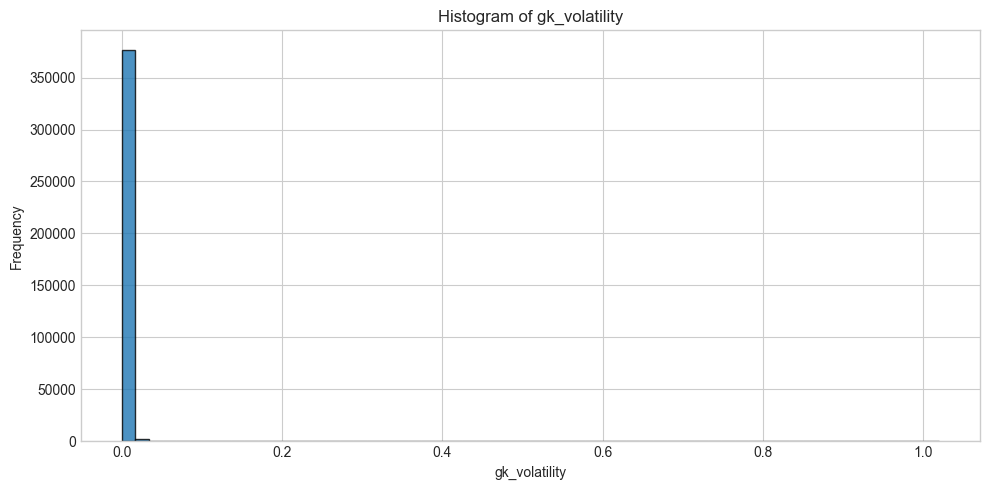

In [8]:
# Histogram: row-level gk_volatility (no aggregation).
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(eda_df["gk_volatility"].dropna(), bins=60, edgecolor="black", alpha=0.8)
ax.set_title("Histogram of gk_volatility")
ax.set_xlabel("gk_volatility")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

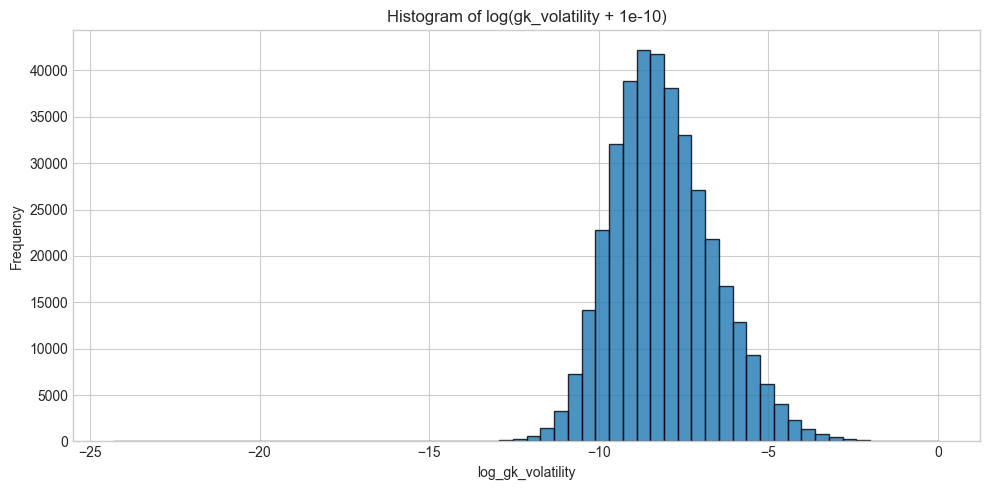

count    379791.000000
mean         -8.094679
std           1.512999
min         -24.277591
25%          -9.156578
50%          -8.230667
75%          -7.149187
max           0.019533
Name: log_gk_volatility, dtype: float64

In [9]:
# Histogram: row-level log_gk_volatility.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(eda_df["log_gk_volatility"].dropna(), bins=60, edgecolor="black", alpha=0.8)
ax.set_title("Histogram of log(gk_volatility + 1e-10)")
ax.set_xlabel("log_gk_volatility")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

eda_df["log_gk_volatility"].describe()

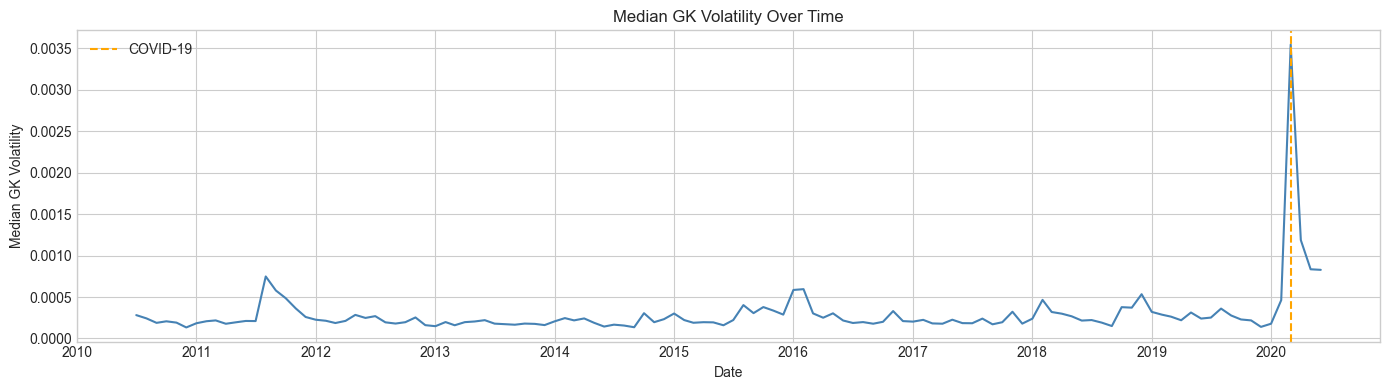

In [10]:
visualize_df = eda_df[["date", "gk_volatility", "log_gk_volatility"]].copy()

visualize_df["date"] = pd.to_datetime(visualize_df["date"])
visualize_df["year"] = visualize_df["date"].dt.year
visualize_df["month"] = visualize_df["date"].dt.to_period("M")

monthly_vol = visualize_df.groupby("month")["gk_volatility"].median().reset_index()
monthly_vol["month"] = monthly_vol["month"].dt.to_timestamp()

plt.figure(figsize=(14, 4))
plt.plot(monthly_vol["month"], monthly_vol["gk_volatility"], color="steelblue")
plt.axvline(
    pd.Timestamp("2020-03-01"), color="orange", linestyle="--", label="COVID-19"
)
plt.title("Median GK Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Median GK Volatility")
plt.legend()
plt.tight_layout()
plt.show()

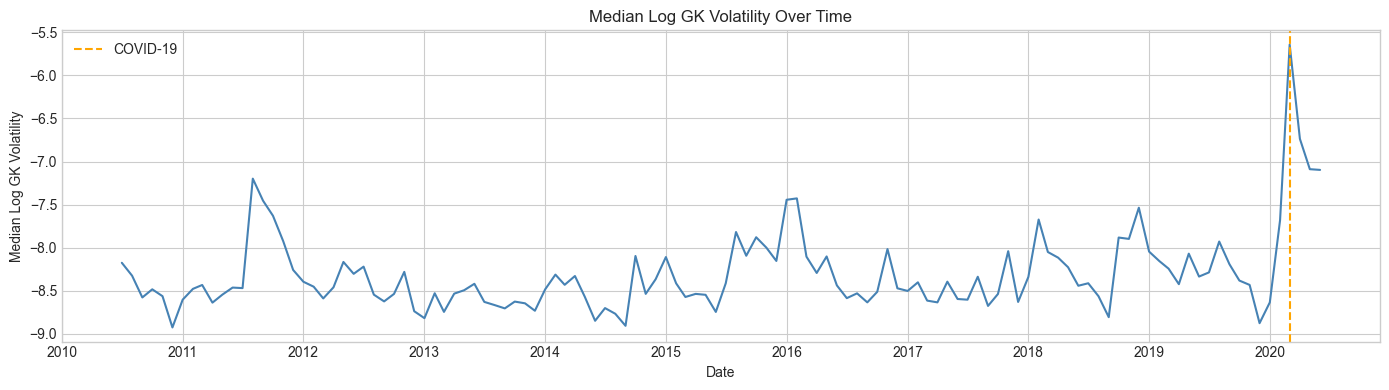

In [11]:
monthly_log_vol = (
    visualize_df.groupby("month")["log_gk_volatility"].median().reset_index()
)
monthly_log_vol["month"] = monthly_log_vol["month"].dt.to_timestamp()

plt.figure(figsize=(14, 4))
plt.plot(
    monthly_log_vol["month"], monthly_log_vol["log_gk_volatility"], color="steelblue"
)
plt.axvline(
    pd.Timestamp("2020-03-01"), color="orange", linestyle="--", label="COVID-19"
)
plt.title("Median Log GK Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Median Log GK Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Save row-level output only.
row_output_path = Path("data/expanded_equities_merged_day_gk_hist.parquet")

eda_save = eda_df.copy()
eda_save.to_parquet(row_output_path, index=False)

print("saved row-level file:", row_output_path.resolve())
print("row-level shape     :", eda_save.shape)

saved row-level file: C:\Users\TT01\cs209b\project\MS3\data\expanded_equities_merged_day_gk_hist.parquet
row-level shape     : (379791, 57)
